# Marching Qubes Vertex Classification with EHands and QCrank
## Brandon Watanabe


In [1]:
# imports, part 1
import numpy as np
import matplotlib.pyplot as plt
import math
from math import pi
import random
import sys
from dotenv import load_dotenv
import os
from pathlib import Path
from collections import defaultdict

import qiskit
from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit.quantum_info import Statevector, Operator, Pauli
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_distribution, array_to_latex
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime.options.sampler_options import SamplerOptions

print(f"Qiskit version: {qiskit.__version__}")

Qiskit version: 2.3.0


In [2]:
# Adapted from Chris Pestano's QSobel
load_dotenv()
data_encoder_circuits_path = os.getenv('DATA_ENCODER_CIRCUITS_PATH')

if data_encoder_circuits_path is None:
    raise EnvironmentError("DATA_ENCODER_CIRCUITS_PATH environment variable is not set. Please set it to the path of data-encoder-circuits.")

print(f"Using DATA_ENCODER_CIRCUITS_PATH from environment variable: {data_encoder_circuits_path}")
circuits_path = data_encoder_circuits_path

# Add to sys.path if not already present
if circuits_path not in sys.path:
    sys.path.insert(0, circuits_path)

print(f"Added to sys.path: {circuits_path}")
print(f"Current working directory: {os.getcwd()}")

from datacircuits.ParametricQCrankV2 import ParametricQCrankV2 as QCrankV2, analyze_qcrank_residuals

Using DATA_ENCODER_CIRCUITS_PATH from environment variable: C:\Users\waffles\Documents\school_work\QC-Classes\References\repos\data-encoder-circuits
Added to sys.path: C:\Users\waffles\Documents\school_work\QC-Classes\References\repos\data-encoder-circuits
Current working directory: c:\Users\waffles\Documents\school_work\QC-Classes\Marching-Qubes-Thesis


In [3]:
sim = AerSimulator()

print(sim)
print(f"\nConfiguration: {sim.configuration()}")

if hasattr(sim, 'available_methods'):
    print(f"Available methods: {sim.available_methods()}")
else:
    print(sim.configuration())

if hasattr(sim, 'available_devices'):
    print(f"Available devices: {sim.available_devices()}")
else:
    print(sim.configuration())   

AerSimulator('aer_simulator')

Configuration: <qiskit_aer.backends.backendconfiguration.AerBackendConfiguration object at 0x0000018548A72210>
Available methods: ('automatic', 'statevector', 'density_matrix', 'stabilizer', 'matrix_product_state', 'extended_stabilizer', 'unitary', 'superop')
Available devices: ('CPU',)


In [4]:
def run_sim_job(qc, n_shots = 2**8, verbose=False):
    """ 
    Run a quantum circuit on the simulator and return the counts.
    
    :param qc: QuantumCircuit to run
    :param n_shots: Number of shots to run the circuit for
    :param verbose: If True, print the circuit and counts

    :return: Counts of the measurement outcomes
    """

    transpiled_circuit = transpile(qc, sim)    
    job = sim.run(transpiled_circuit, shots=n_shots)
    result = job.result()
    
    # Get counts and output distribution
    counts = result.get_counts(transpiled_circuit)

    if verbose:
        print("Circuit before transpilation")
        display(qc.draw('mpl'))
        print("Circuit after transpilation")
        display(transpiled_circuit.draw('mpl', style="iqp"))

        print("Counts:")
        print(counts)
        display(plot_distribution(counts))

    return counts

In [5]:
def display_statevector(qc):
    """
    Display the statevector, unitary matrix, and Bloch sphere representation of a quantum circuit.

    :param qc: QuantumCircuit to analyze

    :return: Statevector of the quantum circuit
    """
    # Get Statevector
    state = Statevector.from_instruction(qc)

    # Display Statevector
    print("\nStatevector:")
    display(state.draw("latex"))

    matrix_form = np.array(state).reshape(-1, 1)
    print("\nStatevector as a matrix:")
    display(array_to_latex(matrix_form))
    
    # Display the Unitary Matrix
    print("Unitary matrix:")
    display(Operator(qc).draw("latex"))

    # Display Bloch Sphere
    display(plot_bloch_multivector(state))

    return state

In [6]:
def plot_residuals(actual, theory, title, x_label, y_label, legend):
    min_val = min(min(actual), min(theory))
    max_val = max(max(actual), max(theory))

    plt.scatter(theory, actual, label=legend)
    # calculate slope of line of best fit
    coefficients = np.polyfit(theory, actual, 1)
    print(f"Slope of line of best fit: {coefficients[0]:.4f}")
    # plot line of best fit
    plt.plot(theory, np.poly1d(coefficients)(theory), color='red', label='Line of Best Fit')    

    plt.xlabel(x_label)    
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend()

    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)
    plt.gca().set_aspect('equal', adjustable='box')

    plt.grid(True)

    plt.show()

In [7]:
def ehands_addition(qc, q_a, q_b, weight, negation=False, verbose=False, barrier=False):
    """ 
    Perform an EHands addition of two qubits with a given weight and optional negation.

    :param qc: QuantumCircuit to which the addition will be applied
    :param q_a: Index of the first qubit
    :param q_b: Index of the second qubit
    :param weight: Weight for the addition (between 0 and 1)
    :param negation: If True, negate the second qubit before addition

    :return: QuantumCircuit with the eHANDS addition applied   
    """
    alpha = np.arccos(1 - 2 * weight)

    qc_add = QuantumCircuit(2)

    if barrier:
        qc_add.barrier()

    if negation:
        qc_add.x(1)

    qc_add.rz(pi/2, 1)
    qc_add.cx(0, 1)
    qc_add.ry(alpha/2, 0)
    qc_add.cx(1, 0) 
    qc_add.ry(-alpha/2, 0)

    if barrier:
        qc_add.barrier()

    if verbose:
        print("Addition Circuit:")
        display(qc_add.draw('mpl'))
    
    return qc.compose(qc_add, qubits=[q_a, q_b])


## Subtraction Setup with QCrank

In [8]:
def configure_qcrank_options(n_shots):
    options = SamplerOptions()
    options.default_shots=n_shots
    return options

In [9]:
def run_sim_job_qcrank(encoding_args, n_cubes, n_shots = 2**12, verbose=False):
    """ 
    Run a quantum circuit on the simulator and return the counts.
    
    :param encoding_args: dictionary including information about the QC of encoded data
    :param n_cubes: number of cubes being processed
    :param n_shots: number of shots to run
    :param verbose: print out extra details and draw circuit

    :return: Counts of the measurement outcomes
    """
    options = configure_qcrank_options(n_shots)
    sampler = Sampler(mode=sim, options=options)

    job = sampler.run(tuple(encoding_args['qcEL']))
    jobRes = job.result()

    #countsL = [jobRes[i].data.meas.get_counts() for i in range(n_cubes)]
    countsL = [jobRes[i].data.c.get_counts() for i in range(n_cubes)]

    if verbose:
        qc = encoding_args['qc']
        cxDepth=qc.depth(filter_function=lambda x: x.operation.name == 'cx')
        print(f'.... PARAMETRIZED CIRCUIT .............. n_cubes={n_cubes}, cx-depth={cxDepth}')
        print('Gates count:', qc.count_ops())
        display(qc.draw('mpl'))


    return countsL

## Notes 03/09/26

look into plotting statistical error for binomial distr, make a plot like Chris' (y=actual vs x=expected)

give plot titles

just use a few pre-selected weights, don't need to find the optimal weight

when doing the actual subtraction, try 2 different methods:

- method 1: encode isovalue into array of same length as data, then do elementwise subtraction

- method 2: encode Data array using QCrank, encode Isovalue using single Ry gate, subtract data qubit by iso qubit

- method 3: encode isovalue into the weight of the EHands addition, then do subtraction that way (ask Dr. Bethel for more details)

    - let d[i] = data[i]
    - let t = isolevel
    - step 1: compute NEG(t)
    - step 2: compute weight sum of d[i] + NEG(t) using w = 0.5
    - step 3: multiply step 2 by 2.0

when running tests, the standard number of shots is 4k per data point 

there is some bug possibly in the calculation of EV in get_EV()

how long does circuit get for data size N? (compound metric (1 and multi qubit gates))

## Method 1
### Encode Data array using QCrank, encode Isovalue using single Ry gate

In [10]:
def initialize_n_data(n_cubes, n_arr, data_range, make_iso_array=False, isovalue=0.5):
    n_data = n_cubes * (2**3)
    nq_addr = math.ceil(math.log2(n_data))
    nq_data = n_arr

    if make_iso_array:
        n_arr -= 1

    data_inp = [np.random.uniform(data_range[0], data_range[1], (n_data, n_cubes)) for _ in range(n_arr)]

    if make_iso_array:
        data_inp.append(np.full((n_data, n_cubes), isovalue))

    return {
        'n_cubes': n_cubes,
        'n_data': n_data,
        'nq_addr': nq_addr,
        'nq_data': nq_data,
        'num_q': nq_addr + nq_data,
        'addr_qL': range(nq_addr),
        'data_qL': range(nq_addr, nq_addr + nq_data),
        'data_inp': data_inp
    }

In [11]:
def encode_with_qcrank_2(data_args, useCZ=False, measure=True, barrier=True):
    nq_addr = data_args['nq_addr']
    nq_data = data_args['nq_data']

    qcrankObj = QCrankV2(nq_addr, nq_data, useCZ=useCZ, measure=measure, barrier=barrier)

    qc = qcrankObj.circuit

    if len(data_args['data_inp']) > 1:
        combined_arrays = np.stack([data_args['data_inp'][0], data_args['data_inp'][1]], axis=1)
        qcrankObj.bind_data(combined_arrays)
    
    else:
        qcrankObj.bind_data(data_args['data_inp'][0])

    qcEL = qcrankObj.instantiate_circuits()
    return {
        'qc': qc,
        'qcEL': qcEL,
        'nq_addr': nq_addr,
        'nq_data': nq_data,
        'qcrankObj': qcrankObj
    }

In [12]:
def analyze_all_qcrank_residuals(data_args, recoveredL, all_data_list, all_rec_list, verbose=False):
    # Iterate over all input arrays
    for i in range(data_args['nq_data']):
        # Save data and recovered to lists
        all_data_list[i].append(data_args['data_inp'][i])
        all_rec_list[i].append(recoveredL[i])

        # QCrank analysis
        print(f"Analyzing residuals for array {i}")
        analyze_qcrank_residuals(data_args['data_inp'][i], recoveredL[i])
        
        if verbose:
            for j in range(data_args['n_cubes']):
                print(f'\nCube {j} original data:\n', data_args['data_inp'][i][..., j].T)
                print(f'Reconstructed data:\n', recoveredL[i][..., j].T)
                print(f'Difference:\n', (data_args['data_inp'][i][..., j] - recoveredL[i][..., j]).T)
                if i > 2: 
                    break

In [13]:
def test_encode_decode_2_data():
    n_arr = 2
    isovalue = 0.5
    n_cubes = 1
    verbose = True

    all_data_list = [[] for _ in range(n_arr)]
    all_rec_list = [[] for _ in range(n_arr)]
    
    for i in range(20):
        # verbose for first iteration to draw circuit
        if i > 0: verbose = False

        # initialize data and isovalue arrays
        data_args = initialize_n_data(n_cubes, n_arr, (-0.99, 0.99), make_iso_array=True, isovalue=isovalue)

        # encode sample data into qcrank
        qcrank_encoding_args = encode_with_qcrank_2(data_args)

        # Run Simulation
        n_shots = data_args['n_data'] * (2**12)
        countsL = run_sim_job_qcrank(qcrank_encoding_args, n_cubes, n_shots, verbose)

        # Recover the data from QC
        qcrankObj = qcrank_encoding_args['qcrankObj']
        data_rec, data_recErr = qcrankObj.reco_from_yields(countsL)

        recoveredL = []
        recoveredErrL = []
        for i in range(data_args['nq_data']):
            recoveredL.append(data_rec[:, i, :].reshape(data_args['n_data'], 1))
            recoveredErrL.append(data_recErr[:, i, :].reshape(data_args['n_data'], 1))

        shpad = n_shots / 2**data_args['nq_addr']
        print(f'Shots per address: {shpad:.1f}, relative error ~ {1/np.sqrt(shpad):.3f}')

        analyze_all_qcrank_residuals(data_args, recoveredL, all_data_list, all_rec_list, verbose=verbose)
        

    title = 'Original Data vs Reconstructed Data'
    x_label = 'Original Data'
    y_label = 'Reconstructed Data'
    legend = 'Data Points'
    plot_residuals(np.concatenate(all_rec_list[0]).flatten(),
                   np.concatenate(all_data_list[0]).flatten(), 
                   title, x_label, y_label, legend)

    title = 'Original Isovalue Array vs Reconstructed Array'
    x_label = 'Original Isovalue'
    y_label = 'Reconstructed Isovalue'
    legend = 'Data Points'
    plt.hist(np.concatenate(all_rec_list[1]).flatten(), bins=30, color='skyblue', edgecolor='black')
    plt.xlabel(x_label)    
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend()

.... PARAMETRIZED CIRCUIT .............. n_cubes=1, cx-depth=8
Gates count: OrderedDict({'ry': 16, 'cx': 16, 'measure': 5, 'h': 3, 'barrier': 2})


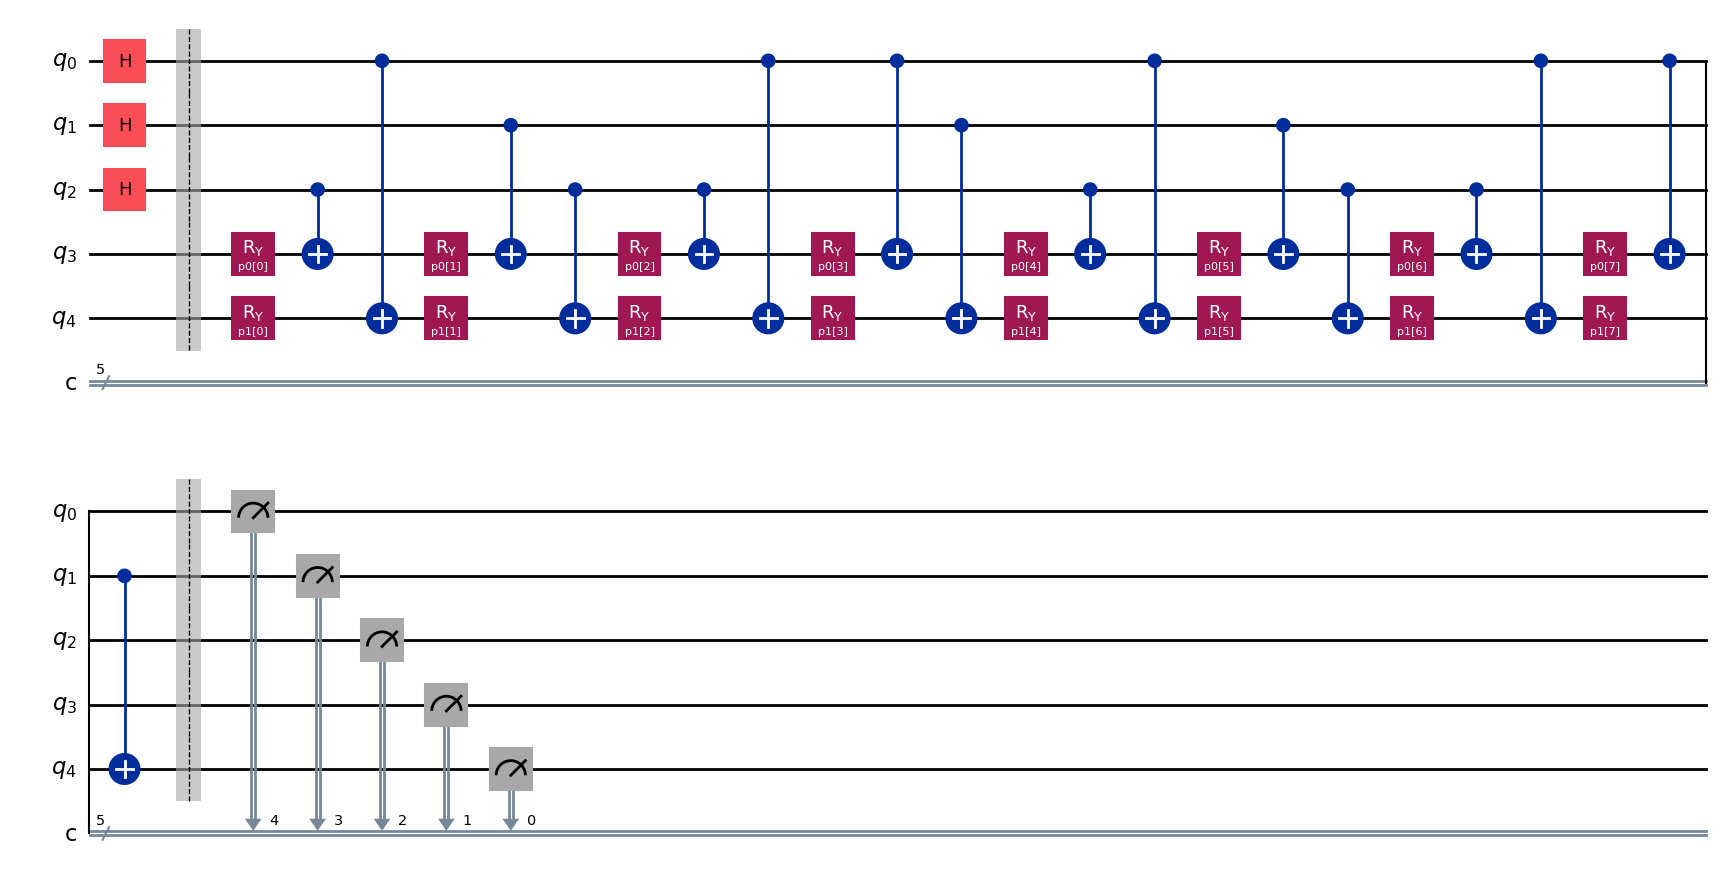

QRFY: nq_addr,nq_data= 3 2  addrBitsL: [2, 3, 4]
Shots per address: 4096.0, relative error ~ 0.016
Analyzing residuals for array 0
  analyze_residuals for 1 imges
img=0  mean=-0.001  std= 0.012  corr=1.00   tilt angle=1.5/deg
Overall 
residuals: mean=-0.001  std=0.012  corr=1.000


Cube 0 original data:
 [ 0.54833738 -0.08192303 -0.63748963  0.91604675  0.2265509  -0.06308466
  0.54878757  0.32523828]
Reconstructed data:
 [ 0.56982422 -0.0908655  -0.64317181  0.90351311  0.24414716 -0.06165049
  0.53842377  0.32899349]
Difference:
 [-0.02148684  0.00894247  0.00568218  0.01253364 -0.01759625 -0.00143417
  0.0103638  -0.00375521]
Analyzing residuals for array 1
  analyze_residuals for 1 imges
img=0  mean= 0.000  std= 0.009  corr=nan   tilt angle=nan/deg
Overall 
residuals: mean=0.000  std=0.009  corr=nan


Cube 0 original data:
 [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
Reconstructed data:
 [0.50439453 0.49988012 0.49828683 0.51608115 0.50167224 0.48446602
 0.50208691 0.49023535]
Difference:
 [

c:\Users\waffles\Documents\school_work\QC-Classes\Marching-Qubes-Thesis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\waffles\Documents\school_work\QC-Classes\Marching-Qubes-Thesis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


QRFY: nq_addr,nq_data= 3 2  addrBitsL: [2, 3, 4]
Shots per address: 4096.0, relative error ~ 0.016
Analyzing residuals for array 0
  analyze_residuals for 1 imges
img=0  mean=-0.003  std= 0.013  corr=1.00   tilt angle=1.1/deg
Overall 
residuals: mean=-0.003  std=0.013  corr=1.000

Analyzing residuals for array 1
  analyze_residuals for 1 imges
img=0  mean=-0.007  std= 0.011  corr=nan   tilt angle=nan/deg
Overall 
residuals: mean=-0.007  std=0.011  corr=nan

QRFY: nq_addr,nq_data= 3 2  addrBitsL: [2, 3, 4]
Shots per address: 4096.0, relative error ~ 0.016
Analyzing residuals for array 0
  analyze_residuals for 1 imges
img=0  mean=-0.000  std= 0.020  corr=1.00   tilt angle=2.2/deg
Overall 
residuals: mean=-0.000  std=0.020  corr=0.999

Analyzing residuals for array 1
  analyze_residuals for 1 imges
img=0  mean= 0.005  std= 0.012  corr=nan   tilt angle=nan/deg
Overall 
residuals: mean=0.005  std=0.012  corr=nan

QRFY: nq_addr,nq_data= 3 2  addrBitsL: [2, 3, 4]
Shots per address: 4096.0, r

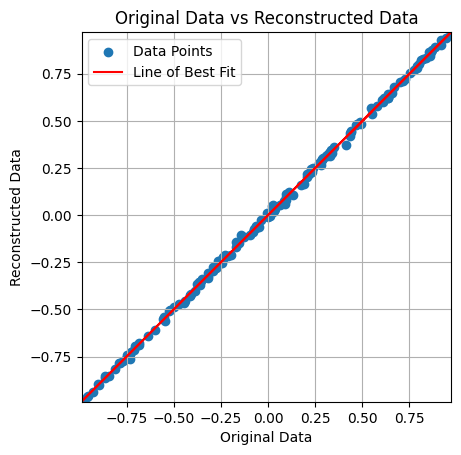

C:\Users\waffles\AppData\Local\Temp\ipykernel_16784\2560197121.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


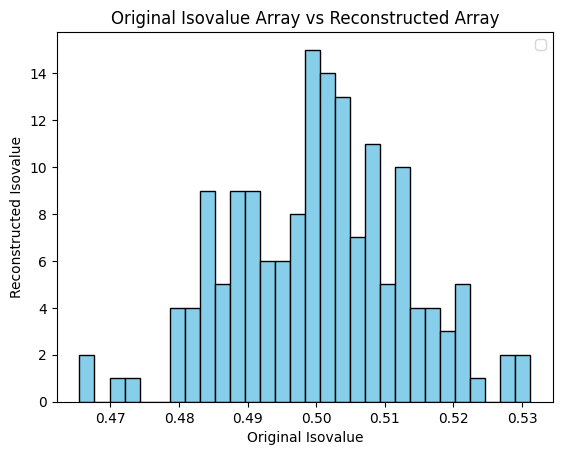

In [14]:
test_encode_decode_2_data()

In [15]:
def test_encode_decode_2_data_manual_measure():
    n_arr = 2
    isovalue = 0.5
    n_cubes = 1
    verbose = True

    all_data_list = [[] for _ in range(n_arr)]
    all_rec_list = [[] for _ in range(n_arr)]
    
    for i in range(20):
        # verbose for first iteration to draw circuit
        if i > 0: verbose = False

        # initialize data and isovalue arrays
        data_args = initialize_n_data(n_cubes, n_arr, (-0.99, 0.99), make_iso_array=True, isovalue=isovalue)

        qc_main = QuantumCircuit(data_args['num_q'], data_args['num_q'])

        # encode sample data into qcrank
        qcrank_encoding_args = encode_with_qcrank_2(data_args, measure=False)

        # Add measurement
        qc_main.compose(qcrank_encoding_args['qcEL'][0], list(range(data_args['num_q'])), inplace=True)
        qc_main.barrier()
        qc_main.measure(list(range(data_args['num_q'])), reversed(list(range(data_args['num_q']))))

        qcrank_encoding_args['qc'] = qc_main
        qcrank_encoding_args['qcEL'] = [qc_main]

        # Run Simulation
        n_shots = data_args['n_data'] * (2**12)
        countsL = run_sim_job_qcrank(qcrank_encoding_args, n_cubes, n_shots, verbose)

        # Recover the data from QC
        qcrankObj = qcrank_encoding_args['qcrankObj']
        data_rec, data_recErr = qcrankObj.reco_from_yields(countsL)

        recoveredL = []
        recoveredErrL = []
        for i in range(data_args['nq_data']):
            recoveredL.append(data_rec[:, i, :].reshape(data_args['n_data'], 1))
            recoveredErrL.append(data_recErr[:, i, :].reshape(data_args['n_data'], 1))

        shpad = n_shots / 2**data_args['nq_addr']
        print(f'Shots per address: {shpad:.1f}, relative error ~ {1/np.sqrt(shpad):.3f}')

        analyze_all_qcrank_residuals(data_args, recoveredL, all_data_list, all_rec_list, verbose=verbose)
        

    title = 'Original Data vs Reconstructed Data'
    x_label = 'Original Data'
    y_label = 'Reconstructed Data'
    legend = 'Data Points'
    plot_residuals(np.concatenate(all_rec_list[0]).flatten(),
                   np.concatenate(all_data_list[0]).flatten(), 
                   title, x_label, y_label, legend)

    title = 'Original Isovalue Array vs Reconstructed Array'
    x_label = 'Original Isovalue'
    y_label = 'Reconstructed Isovalue'
    legend = 'Data Points'
    plt.hist(np.concatenate(all_rec_list[1]).flatten(), bins=30, color='skyblue', edgecolor='black')
    plt.xlabel(x_label)    
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend()

.... PARAMETRIZED CIRCUIT .............. n_cubes=1, cx-depth=8
Gates count: OrderedDict({'ry': 16, 'cx': 16, 'measure': 5, 'h': 3, 'barrier': 2})


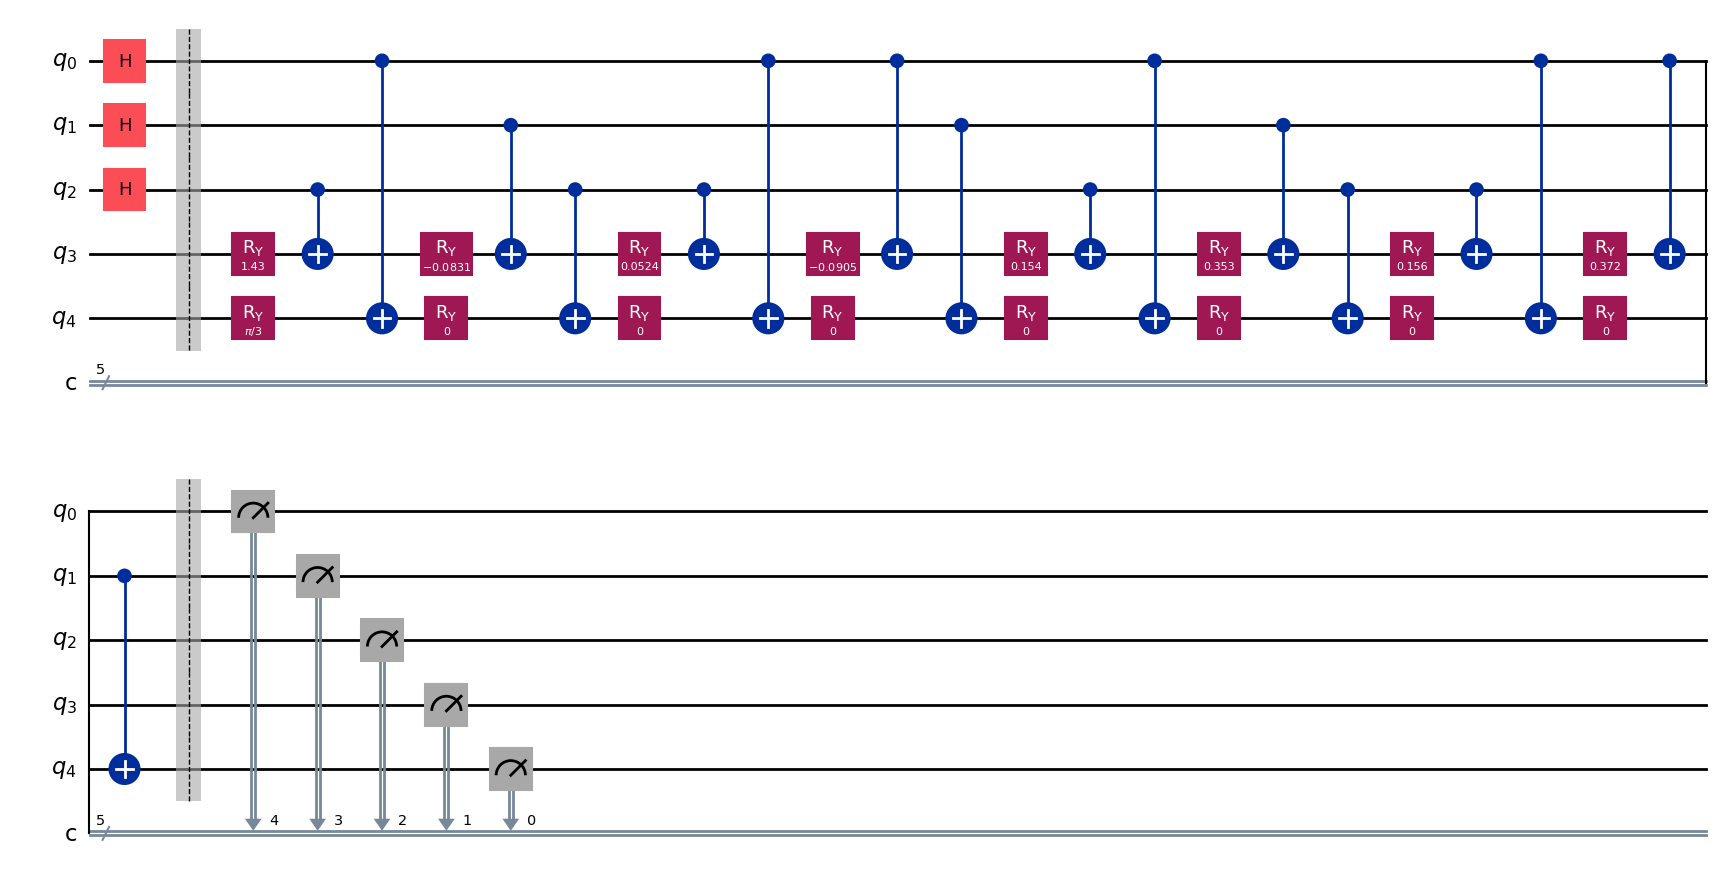

QRFY: nq_addr,nq_data= 3 2  addrBitsL: [2, 3, 4]
Shots per address: 4096.0, relative error ~ 0.016
Analyzing residuals for array 0
  analyze_residuals for 1 imges
img=0  mean= 0.000  std= 0.021  corr=1.00   tilt angle=2.5/deg
Overall 
residuals: mean=0.000  std=0.021  corr=0.999


Cube 0 original data:
 [-0.6947022   0.18595771  0.16868083 -0.47586678  0.963868    0.22130238
  0.20984072  0.3285133 ]
Reconstructed data:
 [-0.70123106  0.19910292  0.18814307 -0.4961165   0.96219846  0.20077407
  0.24907975  0.30519639]
Difference:
 [ 0.00652886 -0.01314521 -0.01946223  0.02024973  0.00166955  0.02052831
 -0.03923904  0.02331691]
Analyzing residuals for array 1
  analyze_residuals for 1 imges
img=0  mean=-0.001  std= 0.010  corr=nan   tilt angle=nan/deg
Overall 
residuals: mean=-0.001  std=0.010  corr=nan


Cube 0 original data:
 [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
Reconstructed data:
 [0.50426136 0.51457762 0.51347379 0.49417476 0.4891818  0.48669569
 0.4998773  0.50280556]
Difference:
 [

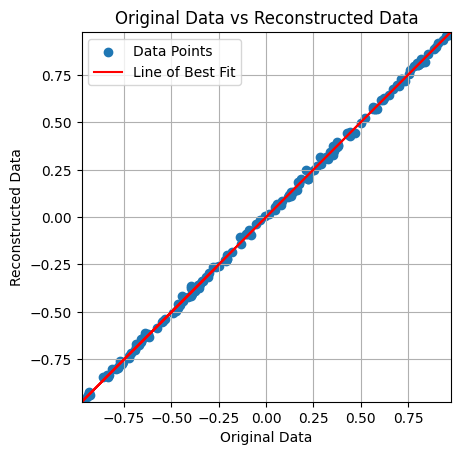

C:\Users\waffles\AppData\Local\Temp\ipykernel_16784\2313898271.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


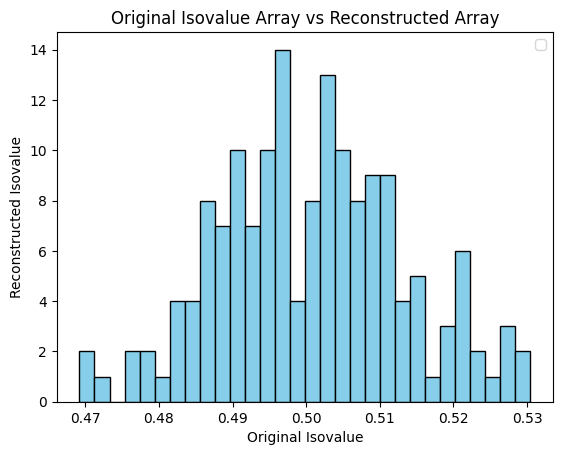

In [16]:
test_encode_decode_2_data_manual_measure()

In [17]:
def test_qcrank_ehands():
    n_arr = 2
    isovalue = 0.5
    weight = 0.5
    n_cubes = 1
    verbose = True

    all_data_list = [[] for _ in range(n_arr)]
    all_rec_list = [[] for _ in range(n_arr)]
    
    for i in range(20):
        # verbose for first iteration to draw circuit
        if i > 0: verbose = False

        # initialize data and isovalue arrays
        data_args = initialize_n_data(n_cubes, n_arr, (-0.99, 0.99), make_iso_array=True, isovalue=isovalue)

        qc_main = QuantumCircuit(data_args['num_q'], data_args['num_q'])

        # encode sample data into qcrank
        qcrank_encoding_args = encode_with_qcrank_2(data_args, measure=False)

        qc_main.compose(qcrank_encoding_args['qcEL'][0], list(range(data_args['num_q'])), inplace=True)

        # Add EHands Addition
        q_a = data_args['data_qL'][0]
        q_b = data_args['data_qL'][1]

        qc_main = ehands_addition(qc_main, q_a, q_b, weight=weight, verbose=verbose, barrier=True)

        # Add measurement
        qc_main.barrier()
        qc_main.measure(list(range(data_args['num_q'])), reversed(list(range(data_args['num_q']))))

        qcrank_encoding_args['qc'] = qc_main
        qcrank_encoding_args['qcEL'] = [qc_main]

        # Run Simulation
        n_shots = data_args['n_data'] * (2**12)
        countsL = run_sim_job_qcrank(qcrank_encoding_args, n_cubes, n_shots, verbose)

        # Recover the data from QC
        qcrankObj = qcrank_encoding_args['qcrankObj']
        data_rec, data_recErr = qcrankObj.reco_from_yields(countsL)

        recoveredL = []
        recoveredErrL = []
        for i in range(data_args['nq_data']):
            recoveredL.append(data_rec[:, i, :].reshape(data_args['n_data'], 1))
            recoveredErrL.append(data_recErr[:, i, :].reshape(data_args['n_data'], 1))

        shpad = n_shots / 2**data_args['nq_addr']
        print(f'Shots per address: {shpad:.1f}, relative error ~ {1/np.sqrt(shpad):.3f}')

        analyze_all_qcrank_residuals(data_args, recoveredL, all_data_list, all_rec_list, verbose=verbose)
        
    print("Returning data and recovered data lists")
    return all_rec_list, all_data_list
    

Addition Circuit:


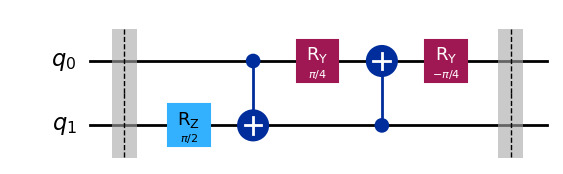

.... PARAMETRIZED CIRCUIT .............. n_cubes=1, cx-depth=10
Gates count: OrderedDict({'ry': 18, 'cx': 18, 'measure': 5, 'barrier': 4, 'h': 3, 'rz': 1})


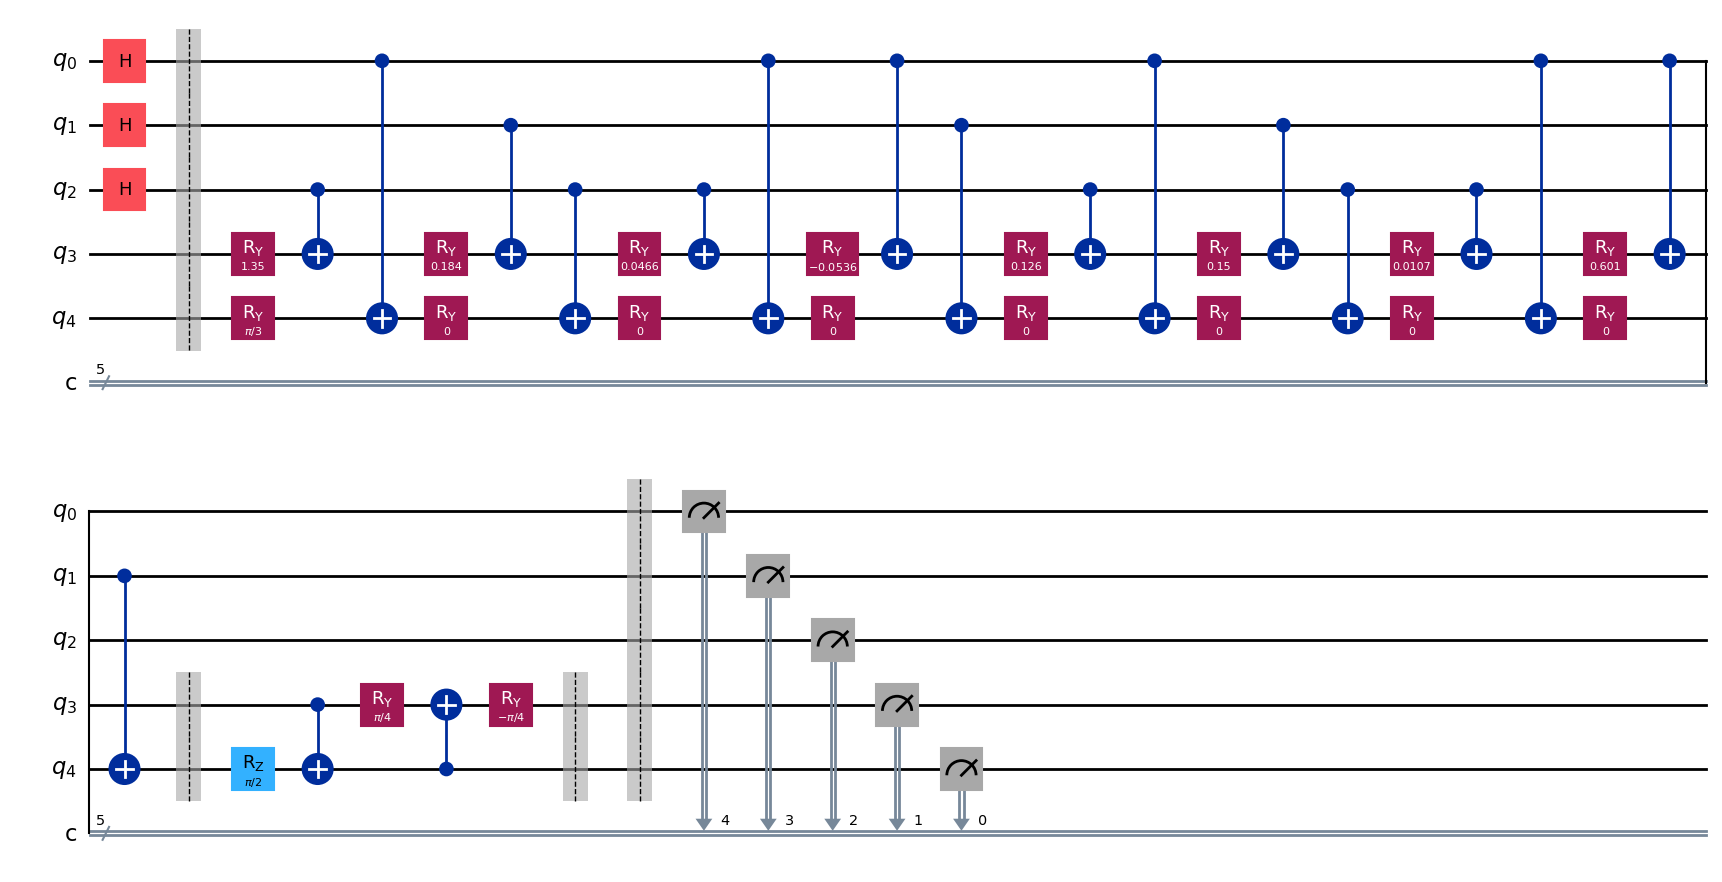

QRFY: nq_addr,nq_data= 3 2  addrBitsL: [2, 3, 4]
Shots per address: 4096.0, relative error ~ 0.016
Analyzing residuals for array 0
  analyze_residuals for 1 imges
img=0  mean=-0.165  std= 0.284  corr=1.00   tilt angle=1.3/deg
Overall 
residuals: mean=-0.165  std=0.284  corr=1.000


Cube 0 original data:
 [-0.74829506 -0.06381632 -0.3024017  -0.30558678  0.80205522  0.8777574
  0.35664665  0.79391823]
Reconstructed data:
 [-0.13676647  0.21313942  0.09494752  0.11013858  0.65438682  0.70093012
  0.43563133  0.65500124]
Difference:
 [-0.61152859 -0.27695574 -0.39734922 -0.41572536  0.14766841  0.17682727
 -0.07898468  0.13891699]
Analyzing residuals for array 1
  analyze_residuals for 1 imges
img=0  mean= 0.416  std= 0.289  corr=nan   tilt angle=nan/deg
Overall 
residuals: mean=0.416  std=0.289  corr=nan


Cube 0 original data:
 [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
Reconstructed data:
 [-0.37580838 -0.05867603 -0.14962167 -0.14660832  0.40087252  0.44049606
  0.17617989  0.38545545]
Differe

In [18]:
all_rec_list, all_data_list = test_qcrank_ehands()

In [19]:
def display_results(all_data_list, all_rec_list):
    print("-----------------------------Analysis of Original vs Reconstructed----------------------------------")
    avg_dif = 0
    print("+----------------+----------------+----------------+")
    print("| Original Data  | Reconstructed  | Difference     |")
    print("+----------------+----------------+----------------+")

    for o, r in zip(np.concatenate(all_data_list[0]).flatten(),
                    np.concatenate(all_rec_list[0]).flatten()):
        dif = o - r
        avg_dif += dif
        print(f"| {o:<14.6f} | {r:<14.6f} | {dif:<14.6f} |")

    print("+----------------+----------------+----------------+")

    n_points = len(np.concatenate(all_data_list[0]).flatten())
    avg_dif /= n_points

    print(f"Average Difference: {avg_dif}")


    title = 'Original Data vs Reconstructed Data'
    x_label = 'Original Data'
    y_label = 'Reconstructed Data'
    legend = 'Data Points'
    plot_residuals(np.concatenate(all_rec_list[0]).flatten(),
                    np.concatenate(all_data_list[0]).flatten(), 
                    title, x_label, y_label, legend)

    print("-----------------------------Analysis of Isovalue vs Reconstructed----------------------------------")
    avg_dif = 0
    print("+----------------+----------------+----------------+")
    print("| Original Iso   | Reconstructed  | Difference     |")
    print("+----------------+----------------+----------------+")

    for o, r in zip(np.concatenate(all_data_list[1]).flatten(),
                    np.concatenate(all_rec_list[1]).flatten()):
        dif = o - r
        avg_dif += dif
        print(f"| {o:<14.6f} | {r:<14.6f} | {dif:<14.6f} |")

    print("+----------------+----------------+----------------+")

    n_points = len(np.concatenate(all_data_list[0]).flatten())
    avg_dif /= n_points

    print(f"Average Difference: {avg_dif}")


    title = 'Original Isovalue Array vs Reconstructed Array'
    x_label = 'Original Isovalue'
    y_label = 'Reconstructed Isovalue'
    legend = 'Data Points'
    plt.hist(np.concatenate(all_rec_list[1]).flatten(), bins=30, color='skyblue', edgecolor='black')
    plt.xlabel(x_label)    
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend()

-----------------------------Analysis of Original vs Reconstructed----------------------------------
+----------------+----------------+----------------+
| Original Data  | Reconstructed  | Difference     |
+----------------+----------------+----------------+
| -0.748295      | -0.136766      | -0.611529      |
| -0.063816      | 0.213139       | -0.276956      |
| -0.302402      | 0.094948       | -0.397349      |
| -0.305587      | 0.110139       | -0.415725      |
| 0.802055       | 0.654387       | 0.147668       |
| 0.877757       | 0.700930       | 0.176827       |
| 0.356647       | 0.435631       | -0.078985      |
| 0.793918       | 0.655001       | 0.138917       |
| -0.075127      | 0.201837       | -0.276964      |
| 0.159454       | 0.342758       | -0.183304      |
| 0.115422       | 0.292978       | -0.177557      |
| 0.237909       | 0.378836       | -0.140927      |
| 0.779111       | 0.651746       | 0.127365       |
| -0.955889      | -0.250123      | -0.705767      

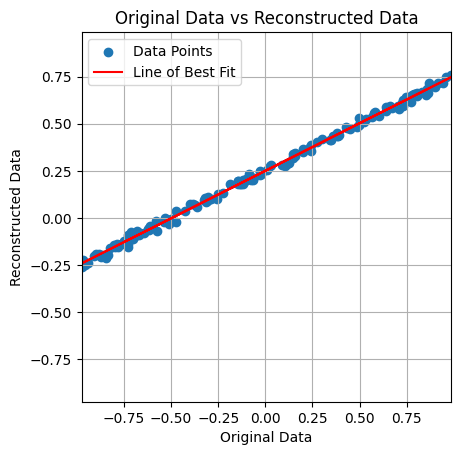

-----------------------------Analysis of Isovalue vs Reconstructed----------------------------------
+----------------+----------------+----------------+
| Original Iso   | Reconstructed  | Difference     |
+----------------+----------------+----------------+
| 0.500000       | -0.375808      | 0.875808       |
| 0.500000       | -0.058676      | 0.558676       |
| 0.500000       | -0.149622      | 0.649622       |
| 0.500000       | -0.146608      | 0.646608       |
| 0.500000       | 0.400873       | 0.099127       |
| 0.500000       | 0.440496       | 0.059504       |
| 0.500000       | 0.176180       | 0.323820       |
| 0.500000       | 0.385455       | 0.114545       |
| 0.500000       | -0.040851      | 0.540851       |
| 0.500000       | 0.068452       | 0.431548       |
| 0.500000       | 0.051332       | 0.448668       |
| 0.500000       | 0.114658       | 0.385342       |
| 0.500000       | 0.413182       | 0.086818       |
| 0.500000       | -0.457087      | 0.957087       

C:\Users\waffles\AppData\Local\Temp\ipykernel_16784\1204628690.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


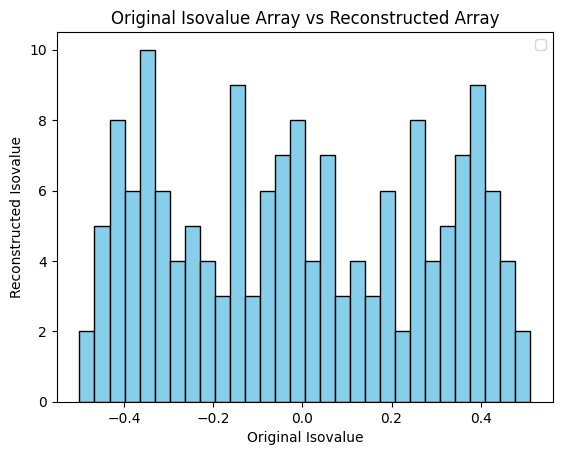

In [20]:
display_results(all_data_list, all_rec_list)

## Method 2
### Encode Data array using QCrank, encode Isovalue using single Ry gate

In [21]:
def test_qcrank_ehands_single_iso():
    n_arr = 1
    isovalue = 0.5
    weight = 0.5
    n_cubes = 1
    verbose = True

    all_data_list = [[] for _ in range(n_arr)]
    all_rec_list = [[] for _ in range(n_arr)]
    
    for i in range(20):
        # verbose for first iteration to draw circuit
        if i > 0: verbose = False

        # initialize data and isovalue arrays
        data_args = initialize_n_data(n_cubes, n_arr, (-0.99, 0.99), make_iso_array=False)

        qc_main = QuantumCircuit(data_args['num_q'] + 1, data_args['num_q'] + 1)

        # encode sample data into qcrank
        qcrank_encoding_args = encode_with_qcrank_2(data_args, measure=False)

        qc_main.compose(qcrank_encoding_args['qcEL'][0], list(range(data_args['num_q'])), inplace=True)

        # add iso value qubit 
        qc_iso = QuantumCircuit(1, 1)
        qc_iso.ry(np.arccos(isovalue), 0)

        qc_main.compose(qc_iso, data_args['num_q'], inplace=True)

        # Add EHands Addition
        q_a = data_args['data_qL'][0]
        q_b = q_a + 1

        print(f"q_a: {q_a}, q_b: {q_b}")

        qc_main = ehands_addition(qc_main, q_a, q_b, weight=weight, verbose=verbose, barrier=True)

        # Add measurement
        qc_main.barrier()
        qc_main.measure(list(range(data_args['num_q'])), reversed(list(range(data_args['num_q']))))

        qcrank_encoding_args['qc'] = qc_main
        qcrank_encoding_args['qcEL'] = [qc_main]

        # Run Simulation
        n_shots = data_args['n_data'] * (2**12)
        countsL = run_sim_job_qcrank(qcrank_encoding_args, n_cubes, n_shots, verbose)

        # Recover the data from QC
        qcrankObj = qcrank_encoding_args['qcrankObj']
        data_rec, data_recErr = qcrankObj.reco_from_yields(countsL)

        recoveredL = []
        recoveredErrL = []
        for i in range(data_args['nq_data']):
            recoveredL.append(data_rec[:, i, :].reshape(data_args['n_data'], 1))
            recoveredErrL.append(data_recErr[:, i, :].reshape(data_args['n_data'], 1))

        shpad = n_shots / 2**data_args['nq_addr']
        print(f'Shots per address: {shpad:.1f}, relative error ~ {1/np.sqrt(shpad):.3f}')

        analyze_all_qcrank_residuals(data_args, recoveredL, all_data_list, all_rec_list, verbose=verbose)
        
    print("Returning data and recovered data lists")
    return all_rec_list, all_data_list
    

q_a: 3, q_b: 4
Addition Circuit:


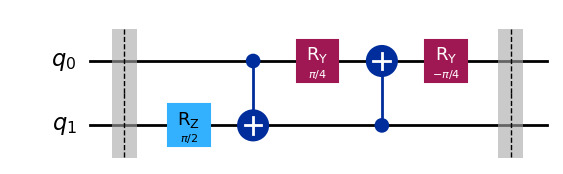

.... PARAMETRIZED CIRCUIT .............. n_cubes=1, cx-depth=10
Gates count: OrderedDict({'ry': 11, 'cx': 10, 'barrier': 4, 'measure': 4, 'h': 3, 'rz': 1})


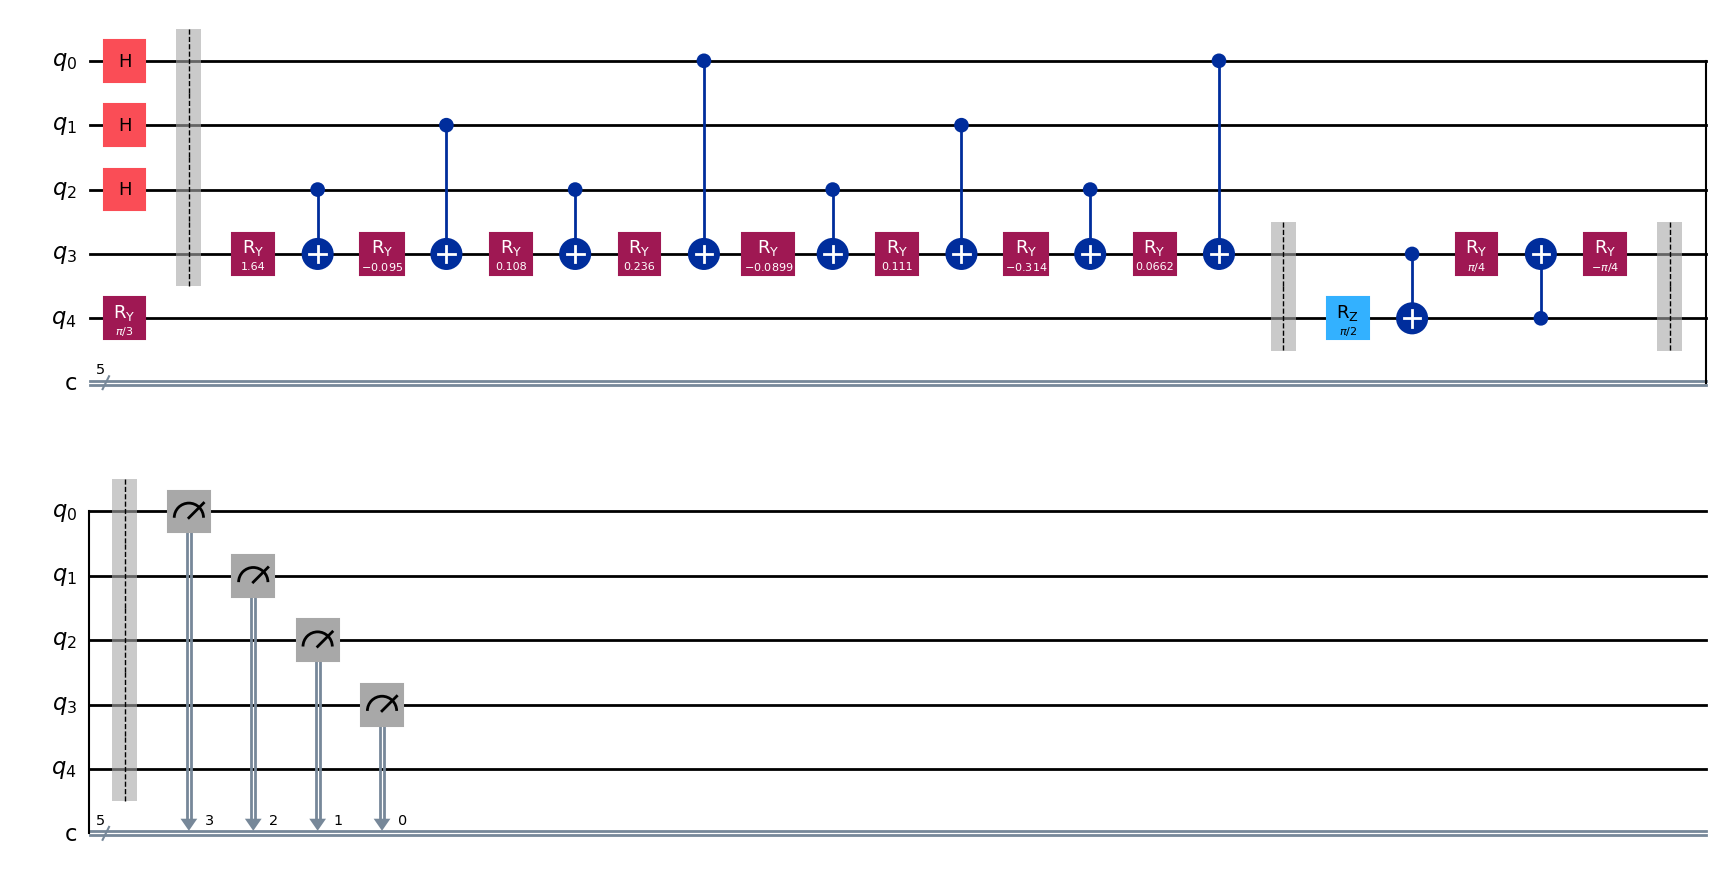

QRFY: nq_addr,nq_data= 3 1  addrBitsL: [1, 2, 3]
Shots per address: 4096.0, relative error ~ 0.016
Analyzing residuals for array 0
  analyze_residuals for 1 imges
img=0  mean=-0.288  std= 0.211  corr=1.00   tilt angle=3.0/deg
Overall 
residuals: mean=-0.288  std=0.211  corr=0.999


Cube 0 original data:
 [-0.09070079 -0.45544036  0.59590041 -0.57872076 -0.51894971 -0.11279695
  0.10003148  0.51873828]
Reconstructed data:
 [ 0.23499142  0.02067623  0.55651135 -0.03775883 -0.00593965  0.18317571
  0.30694062  0.50589971]
Difference:
 [-0.32569221 -0.47611659  0.03938906 -0.54096193 -0.51301006 -0.29597266
 -0.20690914  0.01283857]
q_a: 3, q_b: 4
QRFY: nq_addr,nq_data= 3 1  addrBitsL: [1, 2, 3]
Shots per address: 4096.0, relative error ~ 0.016
Analyzing residuals for array 0
  analyze_residuals for 1 imges
img=0  mean=-0.316  std= 0.287  corr=1.00   tilt angle=3.1/deg
Overall 
residuals: mean=-0.316  std=0.287  corr=0.999

q_a: 3, q_b: 4
QRFY: nq_addr,nq_data= 3 1  addrBitsL: [1, 2, 3]
Sh

In [22]:
all_rec_list, all_data_list = test_qcrank_ehands_single_iso()

-----------------------------Analysis of Original vs Reconstructed----------------------------------
+----------------+----------------+----------------+
| Original Data  | Reconstructed  | Difference     |
+----------------+----------------+----------------+
| -0.090701      | 0.234991       | -0.325692      |
| -0.455440      | 0.020676       | -0.476117      |
| 0.595900       | 0.556511       | 0.039389       |
| -0.578721      | -0.037759      | -0.540962      |
| -0.518950      | -0.005940      | -0.513010      |
| -0.112797      | 0.183176       | -0.295973      |
| 0.100031       | 0.306941       | -0.206909      |
| 0.518738       | 0.505900       | 0.012839       |
| -0.666749      | -0.079812      | -0.586937      |
| -0.561623      | -0.027606      | -0.534017      |
| 0.747166       | 0.621124       | 0.126042       |
| -0.330930      | 0.119519       | -0.450449      |
| -0.494365      | 0.029866       | -0.524231      |
| 0.888903       | 0.689758       | 0.199145       

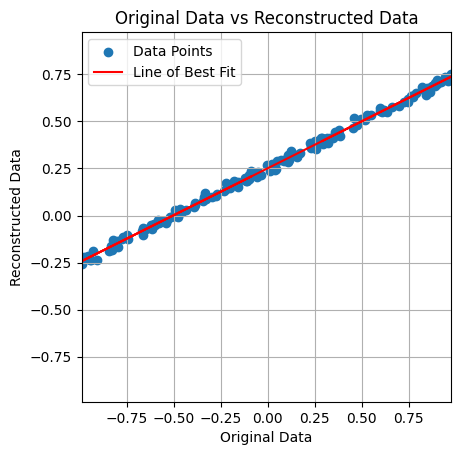

In [23]:
print("-----------------------------Analysis of Original vs Reconstructed----------------------------------")
avg_dif = 0
print("+----------------+----------------+----------------+")
print("| Original Data  | Reconstructed  | Difference     |")
print("+----------------+----------------+----------------+")

for o, r in zip(np.concatenate(all_data_list[0]).flatten(),
                np.concatenate(all_rec_list[0]).flatten()):
    dif = o - r
    avg_dif += dif
    print(f"| {o:<14.6f} | {r:<14.6f} | {dif:<14.6f} |")

print("+----------------+----------------+----------------+")

n_points = len(np.concatenate(all_data_list[0]).flatten())
avg_dif /= n_points

print(f"Average Difference: {avg_dif}")


title = 'Original Data vs Reconstructed Data'
x_label = 'Original Data'
y_label = 'Reconstructed Data'
legend = 'Data Points'
plot_residuals(np.concatenate(all_rec_list[0]).flatten(),
                np.concatenate(all_data_list[0]).flatten(), 
                title, x_label, y_label, legend)

## Method 3
### Encode isovalue into the weight of the EHands addition

In [24]:
def test_qcrank_ehands_single_iso():
    n_arr = 1
    isovalue = 0.5
    weight = 0.5
    n_cubes = 1
    verbose = True

    all_data_list = [[] for _ in range(n_arr)]
    all_rec_list = [[] for _ in range(n_arr)]
    
    for i in range(20):
        # verbose for first iteration to draw circuit
        if i > 0: verbose = False

        # initialize data and isovalue arrays
        data_args = initialize_n_data(n_cubes, n_arr, (-0.99, 0.99), make_iso_array=False)

        qc_main = QuantumCircuit(data_args['num_q'] + 1, data_args['num_q'] + 1)

        # encode sample data into qcrank
        qcrank_encoding_args = encode_with_qcrank_2(data_args, measure=False)

        qc_main.compose(qcrank_encoding_args['qcEL'][0], list(range(data_args['num_q'])), inplace=True)

        # Add EHands Addition
        q_a = data_args['data_qL'][0]
        q_b = q_a + 1

        qc_main = ehands_addition(qc_main, q_a, q_b, weight=weight, verbose=verbose, barrier=True)

        # Add measurement
        qc_main.barrier()
        qc_main.measure(list(range(data_args['num_q'])), reversed(list(range(data_args['num_q']))))

        qcrank_encoding_args['qc'] = qc_main
        qcrank_encoding_args['qcEL'] = [qc_main]

        # Run Simulation
        n_shots = data_args['n_data'] * (2**12)
        countsL = run_sim_job_qcrank(qcrank_encoding_args, n_cubes, n_shots, verbose)

        # Recover the data from QC
        qcrankObj = qcrank_encoding_args['qcrankObj']
        data_rec, data_recErr = qcrankObj.reco_from_yields(countsL)

        recoveredL = []
        recoveredErrL = []
        for i in range(data_args['nq_data']):
            recoveredL.append(data_rec[:, i, :].reshape(data_args['n_data'], 1))
            recoveredErrL.append(data_recErr[:, i, :].reshape(data_args['n_data'], 1))

        shpad = n_shots / 2**data_args['nq_addr']
        print(f'Shots per address: {shpad:.1f}, relative error ~ {1/np.sqrt(shpad):.3f}')

        analyze_all_qcrank_residuals(data_args, recoveredL, all_data_list, all_rec_list, verbose=verbose)
        
    print("Returning data and recovered data lists")
    return all_rec_list, all_data_list
    

Addition Circuit:


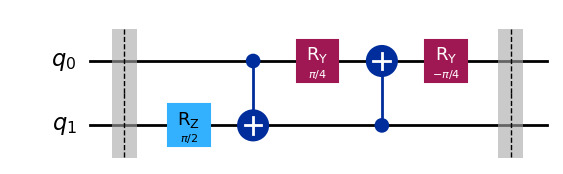

.... PARAMETRIZED CIRCUIT .............. n_cubes=1, cx-depth=10
Gates count: OrderedDict({'ry': 10, 'cx': 10, 'barrier': 4, 'measure': 4, 'h': 3, 'rz': 1})


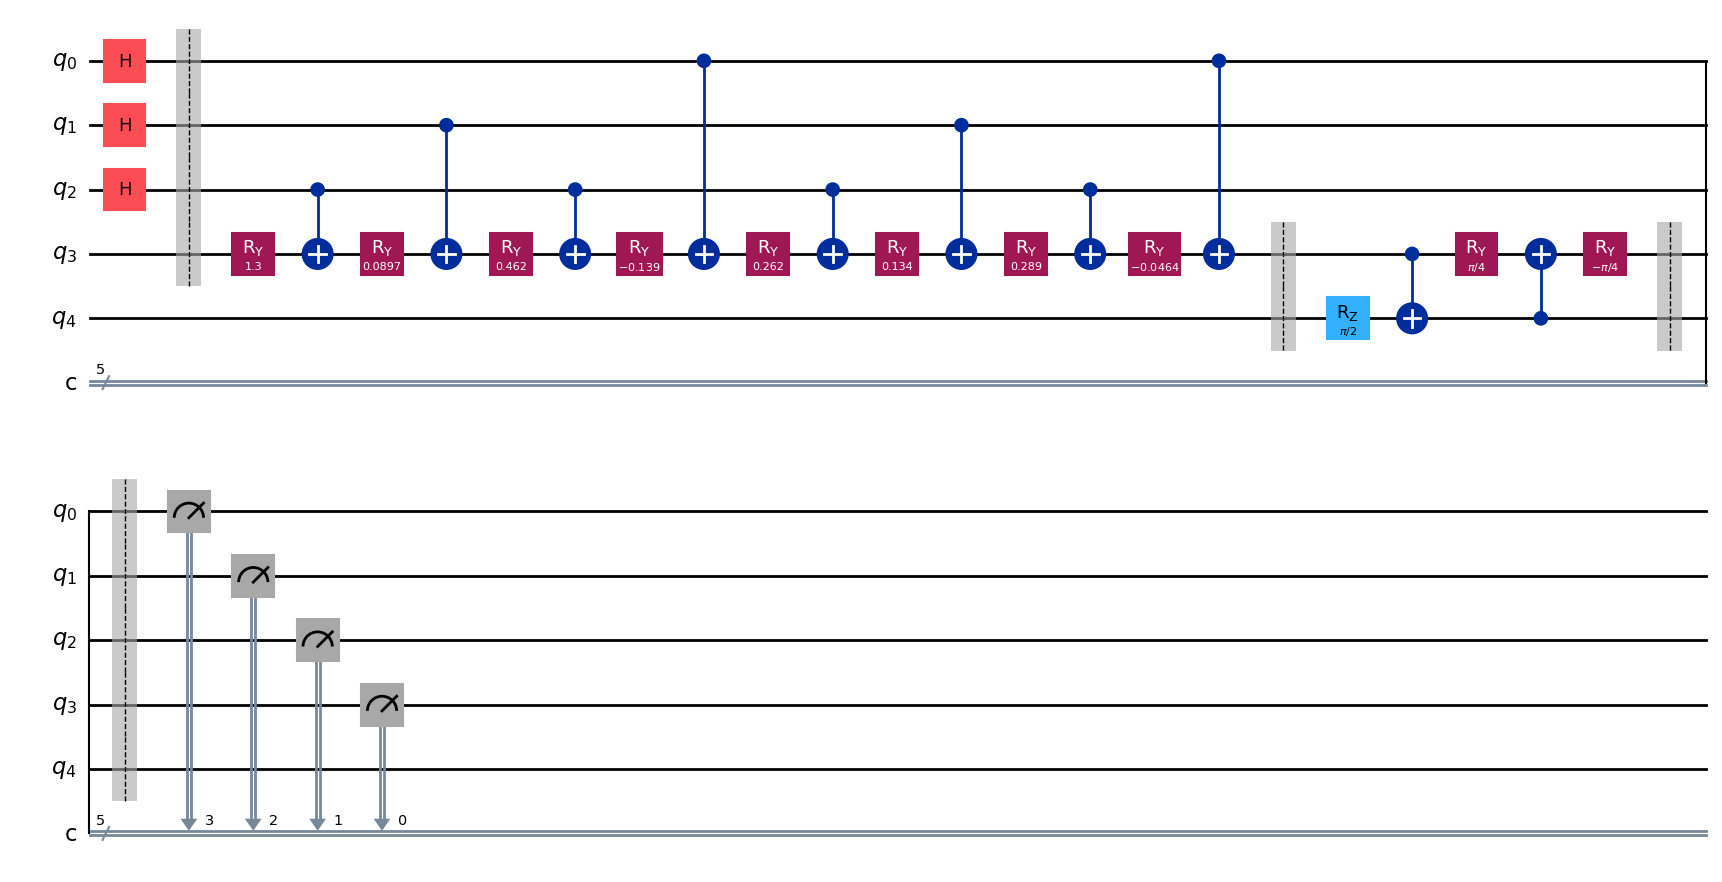

QRFY: nq_addr,nq_data= 3 1  addrBitsL: [1, 2, 3]
Shots per address: 4096.0, relative error ~ 0.016
Analyzing residuals for array 0
  analyze_residuals for 1 imges
img=0  mean=-0.382  std= 0.287  corr=1.00   tilt angle=1.3/deg
Overall 
residuals: mean=-0.382  std=0.287  corr=1.000


Cube 0 original data:
 [-0.70517929  0.91995056  0.61059957  0.22070323  0.4757152   0.68376756
  0.34322319 -0.64835762]
Reconstructed data:
 [0.15776873 0.95701026 0.79853301 0.6054321  0.73751224 0.8496495
 0.6605     0.18665377]
Difference:
 [-0.86294802 -0.0370597  -0.18793344 -0.38472887 -0.26179704 -0.16588195
 -0.31727681 -0.83501139]
QRFY: nq_addr,nq_data= 3 1  addrBitsL: [1, 2, 3]
Shots per address: 4096.0, relative error ~ 0.016
Analyzing residuals for array 0
  analyze_residuals for 1 imges
img=0  mean=-0.515  std= 0.263  corr=1.00   tilt angle=2.6/deg
Overall 
residuals: mean=-0.515  std=0.263  corr=0.999

QRFY: nq_addr,nq_data= 3 1  addrBitsL: [1, 2, 3]
Shots per address: 4096.0, relative error

In [25]:
all_rec_list, all_data_list = test_qcrank_ehands_single_iso()

-----------------------------Analysis of Original vs Reconstructed----------------------------------
+----------------+----------------+----------------+
| Original Data  | Reconstructed  | Difference     |
+----------------+----------------+----------------+
| -0.705179      | 0.157769       | -0.862948      |
| 0.919951       | 0.957010       | -0.037060      |
| 0.610600       | 0.798533       | -0.187933      |
| 0.220703       | 0.605432       | -0.384729      |
| 0.475715       | 0.737512       | -0.261797      |
| 0.683768       | 0.849650       | -0.165882      |
| 0.343223       | 0.660500       | -0.317277      |
| -0.648358      | 0.186654       | -0.835011      |
| 0.421023       | 0.713663       | -0.292640      |
| 0.643000       | 0.837997       | -0.194997      |
| 0.380950       | 0.681930       | -0.300980      |
| -0.664062      | 0.179305       | -0.843367      |
| -0.311467      | 0.322249       | -0.633717      |
| 0.077986       | 0.540701       | -0.462715      

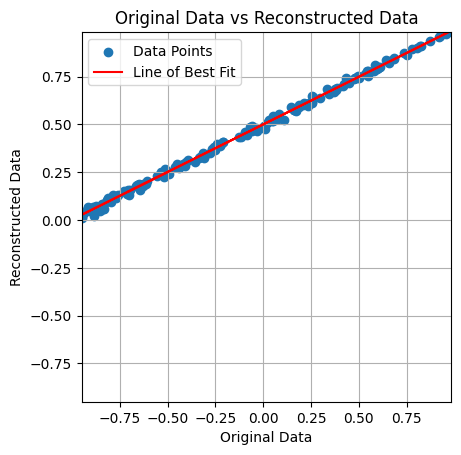

In [26]:
print("-----------------------------Analysis of Original vs Reconstructed----------------------------------")
avg_dif = 0
print("+----------------+----------------+----------------+")
print("| Original Data  | Reconstructed  | Difference     |")
print("+----------------+----------------+----------------+")

for o, r in zip(np.concatenate(all_data_list[0]).flatten(),
                np.concatenate(all_rec_list[0]).flatten()):
    dif = o - r
    avg_dif += dif
    print(f"| {o:<14.6f} | {r:<14.6f} | {dif:<14.6f} |")

print("+----------------+----------------+----------------+")

n_points = len(np.concatenate(all_data_list[0]).flatten())
avg_dif /= n_points

print(f"Average Difference: {avg_dif}")


title = 'Original Data vs Reconstructed Data'
x_label = 'Original Data'
y_label = 'Reconstructed Data'
legend = 'Data Points'
plot_residuals(np.concatenate(all_rec_list[0]).flatten(),
                np.concatenate(all_data_list[0]).flatten(), 
                title, x_label, y_label, legend)